**To identify forest image, im splitting dataset into two, and copied the images to two folders to train the model and counting the files inside the folder .i defined two classes here. Natural_scene folder contains the images of forest and notnatural contains the images of buildings**

i downsampld the dataset , that means i  took 252 forest images and 216 building images for training, testing and validation


In [ ]:
import os

def count_files_in_directory(directory_path):
    if not os.path.isdir(directory_path):
        print(f"Error: Directory '{directory_path}' not found.")
        return 0
    else:
        files = [f for f in os.listdir(directory_path) if os.path.isfile(os.path.join(directory_path, f))]
        return len(files)


natural_scene_path = '/content/sample_data/seg_prediction/Natural_scene'
not_natural_path = '/content/sample_data/seg_prediction/notnatural'

num_files_natural = count_files_in_directory(natural_scene_path)
num_files_not_natural = count_files_in_directory(not_natural_path)

print(f"Number of files in '{natural_scene_path}': {num_files_natural}")
print(f"Number of files in '{not_natural_path}': {num_files_not_natural}")


Number of files in '/content/sample_data/seg_prediction/Natural_scene': 252
Number of files in '/content/sample_data/seg_prediction/notnatural': 216


**splitting the dataset, im givng 80% to train , 10% to validate, 10% test**

In [ ]:
import os
import shutil
import random

def split_dataset(source_dir, train_ratio, val_ratio, test_ratio):
    if not os.path.isdir(source_dir):
        print(f"Error: Source directory '{source_dir}' not found. Skipping split.")
        return

    # Define destination directories
    train_dir = os.path.join(source_dir, 'training')
    val_dir = os.path.join(source_dir, 'validation')
    test_dir = os.path.join(source_dir, 'test')

    # Create directories if they don't exist
    os.makedirs(train_dir, exist_ok=True)
    os.makedirs(val_dir, exist_ok=True)
    os.makedirs(test_dir, exist_ok=True)

    # Get all image files in the source directory
    image_files = [f for f in os.listdir(source_dir) if os.path.isfile(os.path.join(source_dir, f))]
    random.shuffle(image_files)

    total_files = len(image_files)
    num_train = int(total_files * train_ratio)
    num_val = int(total_files * val_ratio)
    num_test = total_files - num_train - num_val # Assign remaining to test to avoid rounding issues

    print(f"Splitting '{source_dir}':")
    print(f"  Total files: {total_files}")
    print(f"  Training files: {num_train}")
    print(f"  Validation files: {num_val}")
    print(f"  Test files: {num_test}")

    # Move files to respective directories
    for i, filename in enumerate(image_files):
        src_path = os.path.join(source_dir, filename)
        if i < num_train:
            shutil.move(src_path, os.path.join(train_dir, filename))
        elif i < num_train + num_val:
            shutil.move(src_path, os.path.join(val_dir, filename))
        else:
            shutil.move(src_path, os.path.join(test_dir, filename))
    print(f"Split complete for '{source_dir}'.\n")

# Define source directories and ratios
base_path = '/content/sample_data/seg_prediction'
natural_scene_source = os.path.join(base_path, 'Natural_scene')
not_natural_source = os.path.join(base_path, 'notnatural')

train_ratio = 0.8
val_ratio = 0.1
test_ratio = 0.1 # This will be the remainder after train and val

# Perform the split for each category
split_dataset(natural_scene_source, train_ratio, val_ratio, test_ratio)
split_dataset(not_natural_source, train_ratio, val_ratio, test_ratio)

print("Dataset splitting complete for both categories.")

Splitting '/content/sample_data/seg_prediction/Natural_scene':
  Total files: 252
  Training files: 201
  Validation files: 25
  Test files: 26
Split complete for '/content/sample_data/seg_prediction/Natural_scene'.

Splitting '/content/sample_data/seg_prediction/notnatural':
  Total files: 216
  Training files: 172
  Validation files: 21
  Test files: 23
Split complete for '/content/sample_data/seg_prediction/notnatural'.

Dataset splitting complete for both categories.


** Model Design and Training**

 the data is splitted, we need to prepare it for the CNN.


In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.optimizers import Adam
import matplotlib.pyplot as plt
import numpy as np
import os
import shutil

# Defining image dimensions and batch size
img_height = 128
img_width = 128
batch_size = 32

# Base path for the dataset
base_path = '/content/sample_data/seg_prediction'



 Data Reorganization for Keras **ImageDataGenerator**

creating a new directory structure where each split (training, validation, test) has its own root folder, and inside these root folders are the class subfolders Natural_scene and notnatural..

In [ ]:
print("Reorganizing dataset for Keras ImageDataGenerator...")

# Define new base directory for the reorganized data
new_base_split_path = os.path.join(base_path, 'seg_prediction_reorganized')

# Define new root directories for the split data
train_root = os.path.join(new_base_split_path, 'train')
val_root = os.path.join(new_base_split_path, 'validation')
test_root = os.path.join(new_base_split_path, 'test')

# Create the new root directories and their class subdirectories
for root_dir in [train_root, val_root, test_root]:
    os.makedirs(os.path.join(root_dir, 'Natural_scene'), exist_ok=True)
    os.makedirs(os.path.join(root_dir, 'notnatural'), exist_ok=True)

# Function to move files from old split structure to new reorganized structure
def move_files_to_new_structure(source_class_name, split_type, dest_root_dir):
    source_dir = os.path.join(base_path, source_class_name, split_type)
    dest_dir = os.path.join(dest_root_dir, source_class_name)

    if os.path.isdir(source_dir):
        print(f"Moving files from '{source_dir}' to '{dest_dir}'...")
        for filename in os.listdir(source_dir):
            shutil.move(os.path.join(source_dir, filename), os.path.join(dest_dir, filename))
    else:
        print(f"Warning: Source directory '{source_dir}' not found. Skipping file movement for this part.")

# Move Natural_scene images
move_files_to_new_structure('Natural_scene', 'training', train_root)
move_files_to_new_structure('Natural_scene', 'validation', val_root)
move_files_to_new_structure('Natural_scene', 'test', test_root)

# Move notnatural images
move_files_to_new_structure('notnatural', 'training', train_root)
move_files_to_new_structure('notnatural', 'validation', val_root)
move_files_to_new_structure('notnatural', 'test', test_root)

print("Dataset reorganization complete.")


Reorganizing dataset for Keras ImageDataGenerator...
Moving files from '/content/sample_data/seg_prediction/Natural_scene/training' to '/content/sample_data/seg_prediction/seg_prediction_reorganized/train/Natural_scene'...
Moving files from '/content/sample_data/seg_prediction/Natural_scene/validation' to '/content/sample_data/seg_prediction/seg_prediction_reorganized/validation/Natural_scene'...
Moving files from '/content/sample_data/seg_prediction/Natural_scene/test' to '/content/sample_data/seg_prediction/seg_prediction_reorganized/test/Natural_scene'...
Moving files from '/content/sample_data/seg_prediction/notnatural/training' to '/content/sample_data/seg_prediction/seg_prediction_reorganized/train/notnatural'...
Moving files from '/content/sample_data/seg_prediction/notnatural/validation' to '/content/sample_data/seg_prediction/seg_prediction_reorganized/validation/notnatural'...
Moving files from '/content/sample_data/seg_prediction/notnatural/test' to '/content/sample_data/seg

 Data Generators

 using ImageDataGenerator to load images from the reorganized directories. and rescale pixel values to [0, 1]. For the training generator, addng augmentation techniques
 .

In [ ]:
# Create data generators for training, validation, and test sets

# Training generator (with rescaling)
train_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    train_root,
    target_size=(img_height, img_width),
    batch_size=batch_size,
    class_mode='binary'
)

# Validation generator (with rescaling)
val_datagen = ImageDataGenerator(rescale=1./255)

val_generator = val_datagen.flow_from_directory(
    val_root,
    target_size=(img_height, img_width),
    batch_size=batch_size,
    class_mode='binary'
)

# Test generator (with rescaling)
test_datagen = ImageDataGenerator(rescale=1./255)

test_generator = test_datagen.flow_from_directory(
    test_root,
    target_size=(img_height, img_width),
    batch_size=batch_size,
    class_mode='binary'
)

# Display class labels and their corresponding indices
print("\nClass labels and their indices (from training generator):", train_generator.class_indices)


Found 373 images belonging to 2 classes.
Found 46 images belonging to 2 classes.
Found 49 images belonging to 2 classes.

Class labels and their indices (from training generator): {'Natural_scene': 0, 'notnatural': 1}


 CNN Model Architecture

defining CNN for this binary classification task.

In [ ]:
# Build the CNN model
model = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(img_height, img_width, 3)),
    MaxPooling2D((2, 2)),

    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),

    Conv2D(128, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),

    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5), # Dropout for regularization
    Dense(1, activation='sigmoid') # Sigmoid activation for binary classification
])

# Compile the model
model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])

# Display model summary
model.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,304,769 (12.61 MB)

 Trainable params: 3,304,769 (12.61 MB)

 Non-trainable params: 0 (0.00 B)

 Model Training



In [ ]:
# Train the model
# Calculate steps per epoch based on the number of samples and batch size
steps_per_epoch_train = train_generator.samples // batch_size
validation_steps_val = val_generator.samples // batch_size

history = model.fit(
    train_generator,
    steps_per_epoch=steps_per_epoch_train,
    epochs=10,
    validation_data=val_generator,
    validation_steps=validation_steps_val
)


Epoch 1/10
11/11 ━━━━━━━━━━━━━━━━━━━━ 15s 1s/step - accuracy: 0.4943 - loss: 0.7553 - val_accuracy: 0.6875 - val_loss: 0.6853
Epoch 2/10
 1/11 ━━━━━━━━━━━━━━━━━━━━ 6s 614ms/step - accuracy: 0.7143 - loss: 0.6905

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 64ms/step - accuracy: 0.7143 - loss: 0.6905 - val_accuracy: 0.5938 - val_loss: 0.6887
Epoch 3/10
11/11 ━━━━━━━━━━━━━━━━━━━━ 18s 981ms/step - accuracy: 0.5852 - loss: 0.6871 - val_accuracy: 0.5938 - val_loss: 0.6787
Epoch 4/10
11/11 ━━━━━━━━━━━━━━━━━━━━ 2s 91ms/step - accuracy: 0.7143 - loss: 0.6375 - val_accuracy: 0.6875 - val_loss: 0.6642
Epoch 5/10
11/11 ━━━━━━━━━━━━━━━━━━━━ 11s 960ms/step - accuracy: 0.7273 - loss: 0.6333 - val_accuracy: 0.6875 - val_loss: 0.6132
Epoch 6/10
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 53ms/step - accuracy: 0.7188 - loss: 0.5542 - val_accuracy: 0.7500 - val_loss: 0.5816
Epoch 7/10
11/11 ━━━━━━━━━━━━━━━━━━━━ 20s 1s/step - accuracy: 0.7742 - loss: 0.5320 - val_accuracy: 0.7812 - val_loss: 0.4593
Epoch 8/10
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - accuracy: 0.8438 - loss: 0.4058 - val_accuracy: 0.6875 - val_loss: 0.5473
Epoch 9/10
11/11 ━━━━━━━━━━━━━━━━━━━━ 17s 1s/step - accuracy: 0.7771 - loss: 0.4899 - val_accuracy: 0.8438 - val_loss: 

Visualize Training and Validation Performance



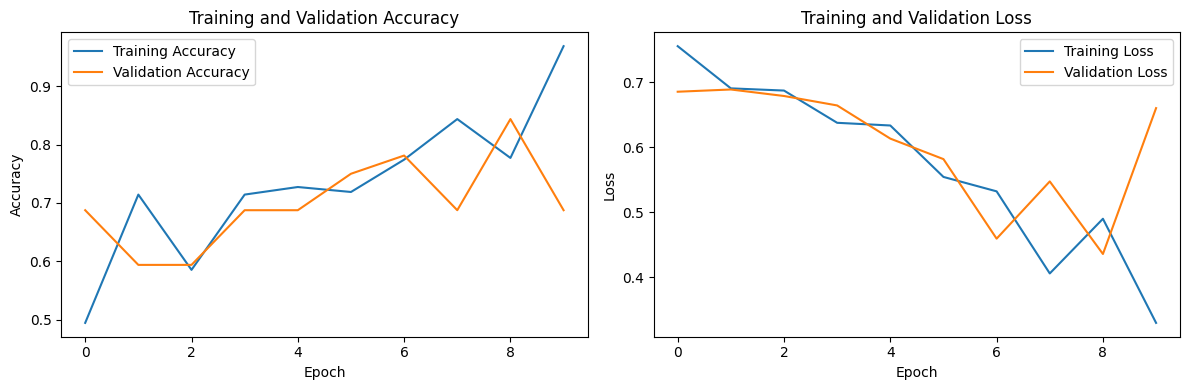

In [ ]:
# Plot training and validation accuracy
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Plot training and validation loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()


 Model Evaluation



Evaluating model on the test dataset...
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 325ms/step - accuracy: 0.7959 - loss: 0.5800

Test Loss: 0.5800
Test Accuracy: 0.7959
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 366ms/step


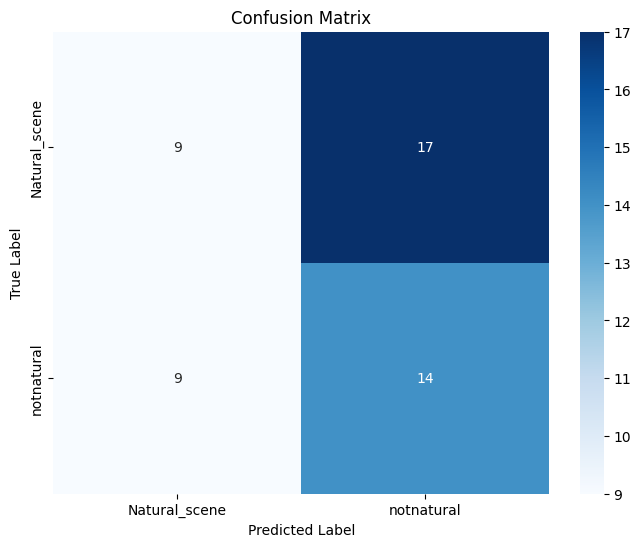


Classification Report:
               precision    recall  f1-score   support

Natural_scene       0.50      0.35      0.41        26
   notnatural       0.45      0.61      0.52        23

     accuracy                           0.47        49
    macro avg       0.48      0.48      0.46        49
 weighted avg       0.48      0.47      0.46        49



In [ ]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

print("\nEvaluating model on the test dataset...")

# evaluatng the model on the test generator
test_loss, test_accuracy = model.evaluate(test_generator)

print(f"\nTest Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")



#Resetng the test generator to ensure predictions are aligned with true labels
test_generator.reset()

# Get true labels
true_labels = test_generator.classes

# Get predicted probabilities
predictions = model.predict(test_generator)

# Convert probabilities to class labels (0 or 1)
predicted_labels = (predictions > 0.5).astype(int)

# Get class names from the generator
class_names = list(test_generator.class_indices.keys())

# Generate Confusion Matrix
cm = confusion_matrix(true_labels, predicted_labels)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

# Generate Classification Report
print("\nClassification Report:")
print(classification_report(true_labels, predicted_labels, target_names=class_names))


 Test a Single Image for Prediction

 creatng  a singl function to load a single image, preprocess it, and use the trained model to predict whether it's a 'Natural_scene' or 'notnatural'.

In [ ]:
from tensorflow.keras.preprocessing import image
import random
import matplotlib.pyplot as plt # Ensure plt is imported for displaying images
import numpy as np # Ensure np is imported for array operations

def predict_single_image(image_path, model_to_use):
    # Load the image and resize it to the target dimensions
    img = image.load_img(image_path, target_size=(img_height, img_width))
    # Convert the image to a numpy array
    img_array = image.img_to_array(img)
    # Expand dimensions to match the input shape of the model (batch_size, img_height, img_width, channels)
    img_array = np.expand_dims(img_array, axis=0)
    # Rescale pixel values (same as during training)
    img_array /= 255.0

    # Make prediction using the specified model
    prediction = model_to_use.predict(img_array)

    # Interpret the prediction
    # For binary classification with sigmoid, values close to 0 mean class 0, and close to 1 mean class 1
    class_indices = train_generator.class_indices
    inverted_class_indices = {v: k for k, v in class_indices.items()}

    # The model predicts a single value. We compare it to 0.5 to determine the class.
    # Assuming 'Natural_scene' is 0 and 'notnatural' is 1 based on train_generator.class_indices
    predicted_class_idx = 1 if prediction[0][0] > 0.5 else 0

    predicted_class_name = inverted_class_indices[predicted_class_idx]

    # Calculate confidence for the predicted class
    confidence = prediction[0][0] if predicted_class_idx == 1 else (1 - prediction[0][0])

    print(f"The image is predicted to be: {predicted_class_name} with confidence {confidence:.2f}")

    # Display the image
    plt.imshow(img)
    plt.title(f"Predicted: {predicted_class_name} ({confidence:.2f})")
    plt.axis('off')
    plt.show()

- Model Refinement - Data Augmentation

To combat overfitting and improve the model's generalization capabilities, we will implement data augmentation on the training set.

 modifyng the `train_datagen` to include operations like rotation, shifting, shearing, zooming, and horizontal flipping. The validation and test generators will remain without augmentation, as they should reflect real-world, unaugmented data.

In [ ]:
# Re-create data generators with augmented training data

# Training generator with augmentation
train_datagen_augmented = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,       # Rotate images by up to 20 degrees
    width_shift_range=0.2,   # Shift images horizontally by up to 20% of width
    height_shift_range=0.2,  # Shift images vertically by up to 20% of height
    shear_range=0.2,         # Shear images by up to 20 degrees
    zoom_range=0.2,          # Zoom in or out by up to 20%
    horizontal_flip=True,    # Randomly flip images horizontally
    fill_mode='nearest'      # Fill newly created pixels with the nearest value
)

train_generator_augmented = train_datagen_augmented.flow_from_directory(
    train_root,
    target_size=(img_height, img_width),
    batch_size=batch_size,
    class_mode='binary'
)

# Validation and Test generators remain the same (only rescaling)
val_datagen = ImageDataGenerator(rescale=1./255)
val_generator = val_datagen.flow_from_directory(
    val_root,
    target_size=(img_height, img_width),
    batch_size=batch_size,
    class_mode='binary'
)

test_datagen = ImageDataGenerator(rescale=1./255)
test_generator = test_datagen.flow_from_directory(
    test_root,
    target_size=(img_height, img_width),
    batch_size=batch_size,
    class_mode='binary'
)

print("Data generators re-created with augmented training data.")

Found 373 images belonging to 2 classes.
Found 46 images belonging to 2 classes.
Found 49 images belonging to 2 classes.
Data generators re-created with augmented training data.


Retrainng the Model with Augmented Data



In [ ]:

model_augmented = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(img_height, img_width, 3)),
    MaxPooling2D((2, 2)),

    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),

    Conv2D(128, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),

    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(1, activation='sigmoid')
])

model_augmented.compile(optimizer='adam',
                        loss='binary_crossentropy',
                        metrics=['accuracy'])

print("Model re-initialized for training with augmented data.")

# Train the model with the augmented generator
steps_per_epoch_train_augmented = train_generator_augmented.samples // batch_size

history_augmented = model_augmented.fit(
    train_generator_augmented,
    steps_per_epoch=steps_per_epoch_train_augmented,
    epochs=15, # Increased epochs as augmentation can make training converge slower
    validation_data=val_generator,
    validation_steps=validation_steps_val
)

print("Model retraining with augmented data complete.")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model re-initialized for training with augmented data.
Epoch 1/15
11/11 ━━━━━━━━━━━━━━━━━━━━ 16s 1s/step - accuracy: 0.4751 - loss: 0.7475 - val_accuracy: 0.3750 - val_loss: 0.7054
Epoch 2/15
 1/11 ━━━━━━━━━━━━━━━━━━━━ 9s 904ms/step - accuracy: 0.5312 - loss: 0.6779

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step - accuracy: 0.5312 - loss: 0.6779 - val_accuracy: 0.4688 - val_loss: 0.6884
Epoch 3/15
11/11 ━━━━━━━━━━━━━━━━━━━━ 20s 2s/step - accuracy: 0.5777 - loss: 0.6800 - val_accuracy: 0.7188 - val_loss: 0.6526
Epoch 4/15
11/11 ━━━━━━━━━━━━━━━━━━━━ 2s 59ms/step - accuracy: 0.7500 - loss: 0.6303 - val_accuracy: 0.6250 - val_loss: 0.6633
Epoch 5/15
11/11 ━━━━━━━━━━━━━━━━━━━━ 41s 2s/step - accuracy: 0.6891 - loss: 0.6030 - val_accuracy: 0.5625 - val_loss: 0.8229
Epoch 6/15
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - accuracy: 0.6562 - loss: 0.6283 - val_accuracy: 0.6250 - val_loss: 0.5800
Epoch 7/15
11/11 ━━━━━━━━━━━━━━━━━━━━ 13s 1s/step - accuracy: 0.6950 - loss: 0.6053 - val_accuracy: 0.7188 - val_loss: 0.6246
Epoch 8/15
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - accuracy: 0.7500 - loss: 0.5721 - val_accuracy: 0.6875 - val_loss: 0.6484
Epoch 9/15
11/11 ━━━━━━━━━━━━━━━━━━━━ 20s 1s/step - accuracy: 0.7683 - loss: 0.5412 - val_accuracy: 0.6250 - val_loss: 0.8582

Visualize Training and Validation Performance (Augmented Model)

 visualizng the training and validation accuracy and loss for the model trained with augmented data to see if overfitting has been reduced and performance has improved.

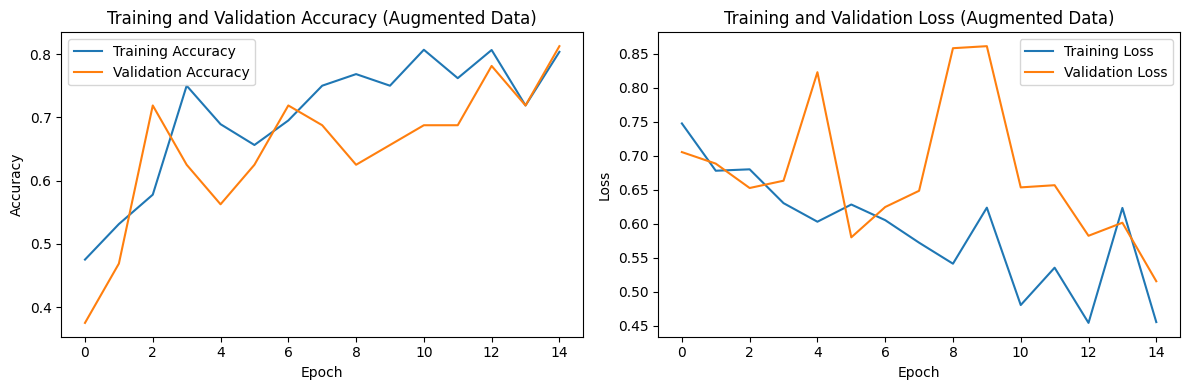

In [ ]:
# plotng trainng and validatn accuracy for the augmented model
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history_augmented.history['accuracy'], label='Training Accuracy')
plt.plot(history_augmented.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training and Validation Accuracy (Augmented Data)')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

#plotng trainng and validatn accuracy for the augmented model
plt.subplot(1, 2, 2)
plt.plot(history_augmented.history['loss'], label='Training Loss')
plt.plot(history_augmented.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss (Augmented Data)')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

Testng a Single forest Image with the Augmented Model

usng `model_augmented` to predict a single, randomly selected forest image from the test set to observe its performance.

Selected natural image for prediction: /content/sample_data/seg_prediction/seg_prediction_reorganized/test/Natural_scene/10092.jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 114ms/step
The image is predicted to be: Natural_scene with confidence 0.62


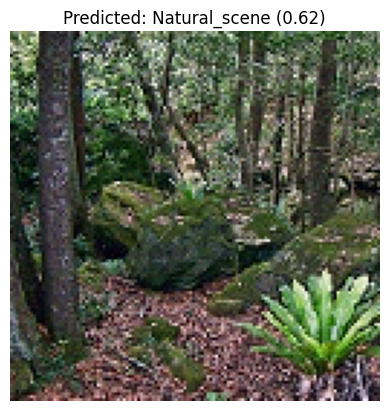

In [ ]:
# dynamically pickng an image from the test set for 'Natural_scene which contains the images of forest'

natural_test_path = os.path.join(test_root, 'Natural_scene')

sample_image_path = None
if os.path.exists(natural_test_path) and os.listdir(natural_test_path):
    sample_image_file = random.choice(os.listdir(natural_test_path))
    sample_image_path = os.path.join(natural_test_path, sample_image_file)
    print(f"Selected forest image for prediction: {sample_image_path}")
else:
    print(f"Error: No 'forest' images found in test directory: {natural_test_path}")

if sample_image_path:
    # Use the model_augmented for prediction
    predict_single_image(sample_image_path, model_augmented)
else:
    print("Please ensure your test directories contain images.")

my Observation : The model predicted the forest image

Streamlet application is not created due to time constraints
